In [3]:
import numpy as np
from dataclasses import dataclass
from functools import partial

import matplotlib.pyplot as plt
from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

import torch

from lingua.optim import build_optimizer, OptimArgs

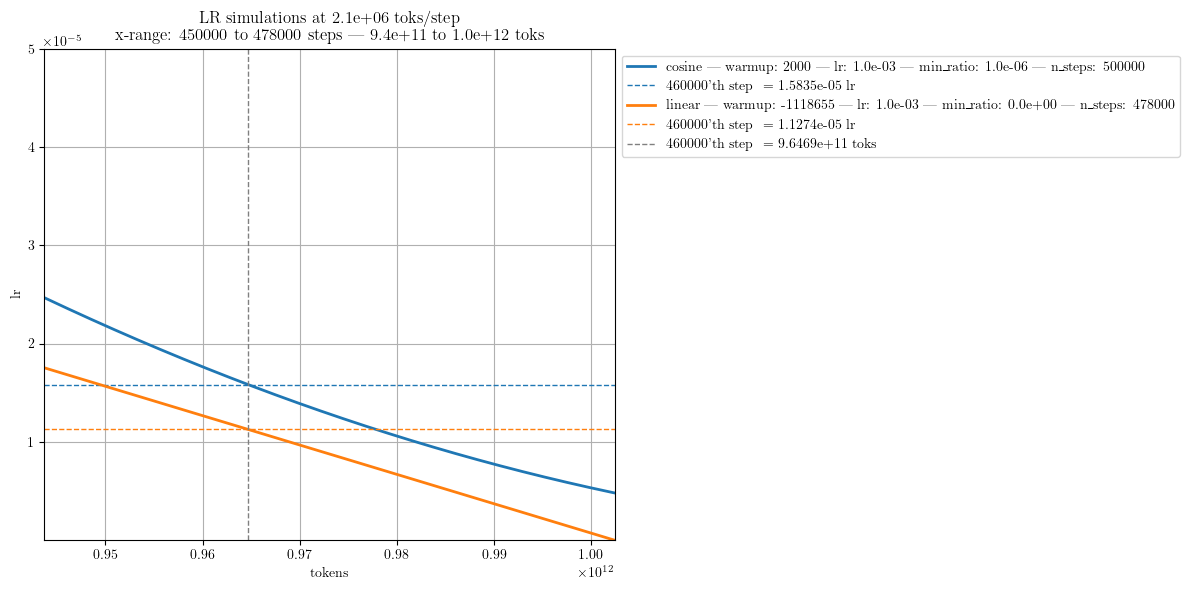

In [47]:
# now plot the lr as a function of step

# overrides = {
#     "scheduler": "cosine",
#     "warmup": 2000,
#     "lr": 1.0e-3,
#     "lr_min_ratio": 0.000001,
# }
# overrides = {
#     "scheduler": "cosine",
#     "warmup": 2000,
#     "lr": 3.0e-4,
#     "lr_min_ratio": 1.0e-1,
# }
# overrides = {
#     "scheduler": "wsd",
#     "warmup": 2000,
#     "lr": 3.0e-4,
#     "lr_min_ratio": 1.0e-4,
#     "decay_fraction": 1.0e-1, # fraction of the total steps for decay
# }
# overrides = {
#     "scheduler": "wsd",
#     "warmup": 2000,
#     "lr": 3.0e-4,
#     "lr_min_ratio": 1.0e-4,
#     "decay_fraction": 3.33333e-1,
# }
# overrides = {
#     "scheduler": "cosine",
#     "warmup": 2000,
#     "lr": 2.0e-3,
#     "lr_min_ratio": 0.000001,
# }

plt.figure(figsize=(12, 6))


base_n_steps = 500_000
toks_per_step_world = 1 * (64*4*2) * 4096

# n_steps = 125_000
# n_steps = 250_000
# toks_per_step = args.grad_acc_steps * args.data.batch_size * args.data.seq_len
# toks_per_step_world = 1 * (128*4*4) * 4096

# x_lim_steps = (0, n_steps)
# y_lim = None
# save_name = f"lr_scheduler_simulation.png"

x_lim_steps = (450_000, 478_000)
y_lim = (1e-8, 5e-5)
save_name = f"lr_scheduler_simulation_zoom.png"


x_lim = (x_lim_steps[0] * toks_per_step_world, x_lim_steps[1] * toks_per_step_world)

# add a v line at a specific step
spec_step = 460_000


# title_string = f"{n_steps} steps @ {toks_per_step_world:.1e} total toks/step"
title_string = f"LR simulations at {toks_per_step_world:.1e} toks/step\nx-range: {x_lim_steps[0]} to {x_lim_steps[1]} steps | {x_lim[0]:.1e} to {x_lim[1]:.1e} toks"
for overrides in [
    {
    "scheduler": "cosine",
    "warmup": 2000,
    "lr": 1.0e-3,
    "lr_min_ratio": 0.000001,
    "n_steps": 500_000,
    },
    {
    "scheduler": "linear",
    "warmup": -1118655,
    "lr": 1e-3,
    "lr_min_ratio": 0.0,
    "n_steps": 478_000,
    },
]:
    n_steps = overrides.pop("n_steps", base_n_steps)

    args = OptimArgs(**overrides)

    # fake model with one parameter
    class FakeModule(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.linear = torch.nn.Linear(10, 10)

        def forward(self, x):
            return x
        def __repr__(self):
            return "fake model"
    model = FakeModule()

    optimizer, scheduler = build_optimizer(model, args, n_steps)

    # all_lrs = [lr_fn(i) for i in range(n_steps)]
    all_lrs = []
    for i in range(n_steps):
        all_lrs.append(optimizer.param_groups[0]["lr"])
        optimizer.step()
        scheduler.step()

    x = np.arange(n_steps)
    x = x * toks_per_step_world
    y = np.array(all_lrs)
    plt.plot(x, y, label=f"{args.scheduler} | warmup: {args.warmup} | lr: {args.lr:.1e} | min_ratio: {args.lr_min_ratio:.1e} | n_steps: {n_steps}", linewidth=2)
    plt.xlabel("tokens")
    plt.ylabel("lr")

    # add an hline at the y value corresponding ~ to the spec_step, matching the color of the line
    spec_lr = all_lrs[spec_step] if spec_step < len(all_lrs) else all_lrs[-1]
    plt.axhline(y=spec_lr, color=plt.gca().lines[-1].get_color(), linestyle='--', linewidth=1, label=f"{spec_step}'th step ~= {spec_lr:.4e} lr")


spec_tok_ct = spec_step * toks_per_step_world
plt.axvline(x=spec_tok_ct, color='gray', linestyle='--', linewidth=1, label=f"{spec_step}'th step ~= {spec_tok_ct:.4e} toks")

plt.xlim(x_lim)

if y_lim is not None:
    plt.ylim(y_lim)

# plt.legend()
# move legend to the right outside the plot but dont squish the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.title(title_string)
plt.grid()
plt.tight_layout()
# plt.show()

plt.savefig(save_name)

## plan for how to stich a linear cooldown to an existing cosine in lingua

In [ ]:
# Colin's hq cd lr cfg block was 

lr: 1e-3
weight_decay: 0.2
warmup: -1118655
lr_min_ratio: 0.0
scheduler: "linear"
clip: 1.0

In [ ]:
1. figure out the slope of the line for decay start to end point and steps
2. If im at this rate, figure out where a triangle peaking at the original peak values step peak _would_ be, could be negative, and then use this as the warmup start point

plot to be sure that it intersects the line at the right point and that the slope is correct and that it hits zero at the desired end step

In [ ]:
We want 10 equally spaced checkpoints across the cooldown duration
so figure out the eval args needed to make sure we save these.

(460/500)*250 = 230

decay from 230k for 9k steps to try and actually nail 2T
